# DQN

Episode 10/2000 | Avg Reward(10): 33.34 | Avg Loss(10): 0.0003 | ExplNoise: 0.2212
Episode 20/2000 | Avg Reward(10): 31.97 | Avg Loss(10): 0.0002 | ExplNoise: 0.1631
Episode 30/2000 | Avg Reward(10): 32.90 | Avg Loss(10): 0.0002 | ExplNoise: 0.1203
Episode 40/2000 | Avg Reward(10): 31.47 | Avg Loss(10): 0.0001 | ExplNoise: 0.0887
Episode 50/2000 | Avg Reward(10): 32.38 | Avg Loss(10): 0.0001 | ExplNoise: 0.0654
Episode 60/2000 | Avg Reward(10): 34.93 | Avg Loss(10): 0.0001 | ExplNoise: 0.0482
Episode 70/2000 | Avg Reward(10): 33.38 | Avg Loss(10): 0.0001 | ExplNoise: 0.0356
Episode 80/2000 | Avg Reward(10): 33.07 | Avg Loss(10): 0.0001 | ExplNoise: 0.0300
Episode 90/2000 | Avg Reward(10): 32.44 | Avg Loss(10): 0.0001 | ExplNoise: 0.0300
Episode 100/2000 | Avg Reward(10): 31.30 | Avg Loss(10): 0.0000 | ExplNoise: 0.0300
Episode 110/2000 | Avg Reward(10): 33.51 | Avg Loss(10): 0.0000 | ExplNoise: 0.0300
Episode 120/2000 | Avg Reward(10): 30.78 | Avg Loss(10): 0.0000 | ExplNoise: 0.0300
E

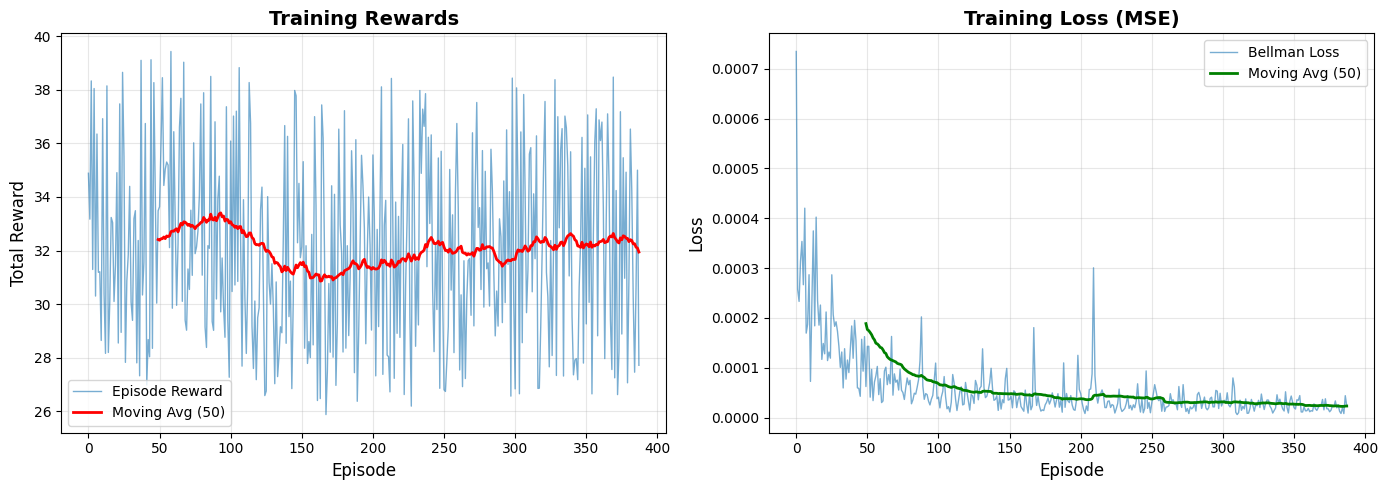

[2/5] Plotting BIS trajectory...


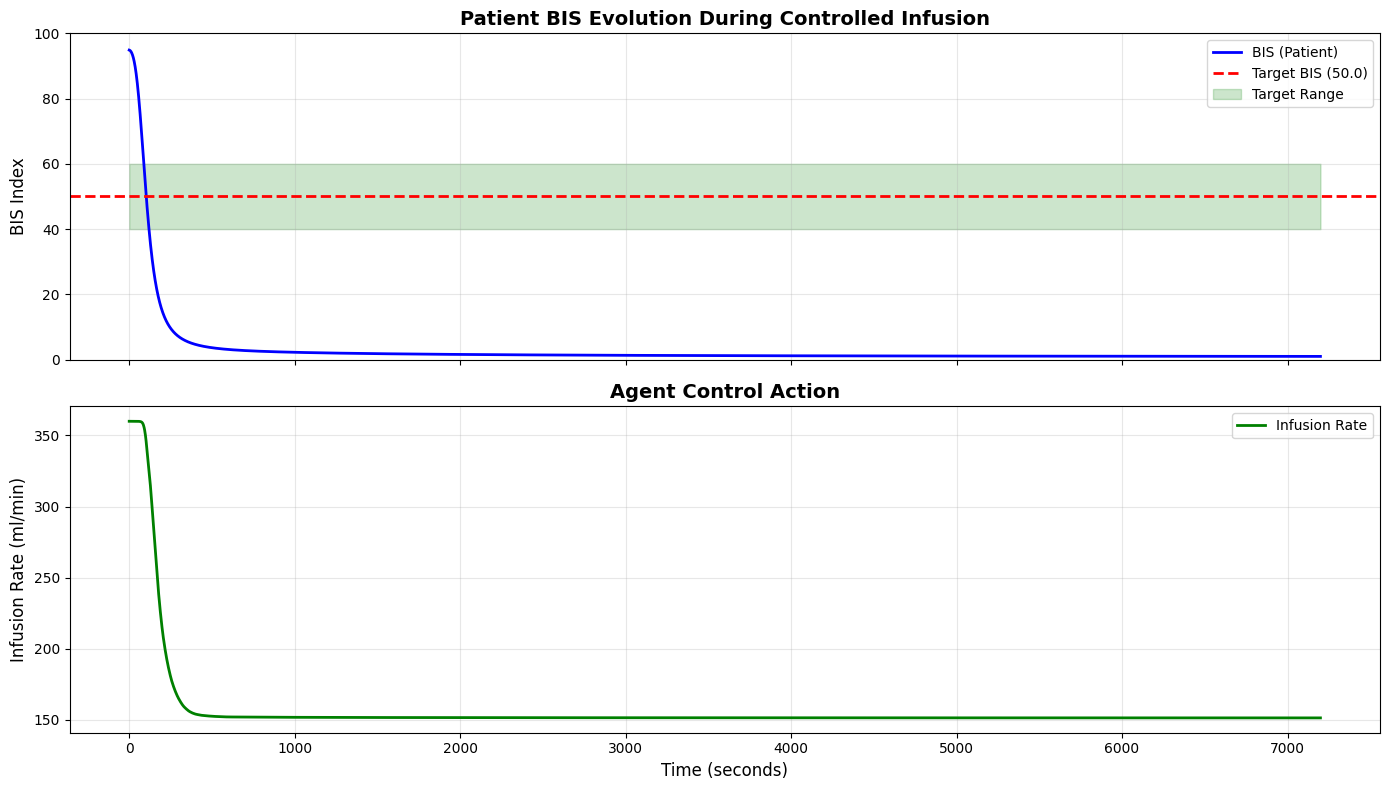

[3/5] Plotting Q-values heatmap...


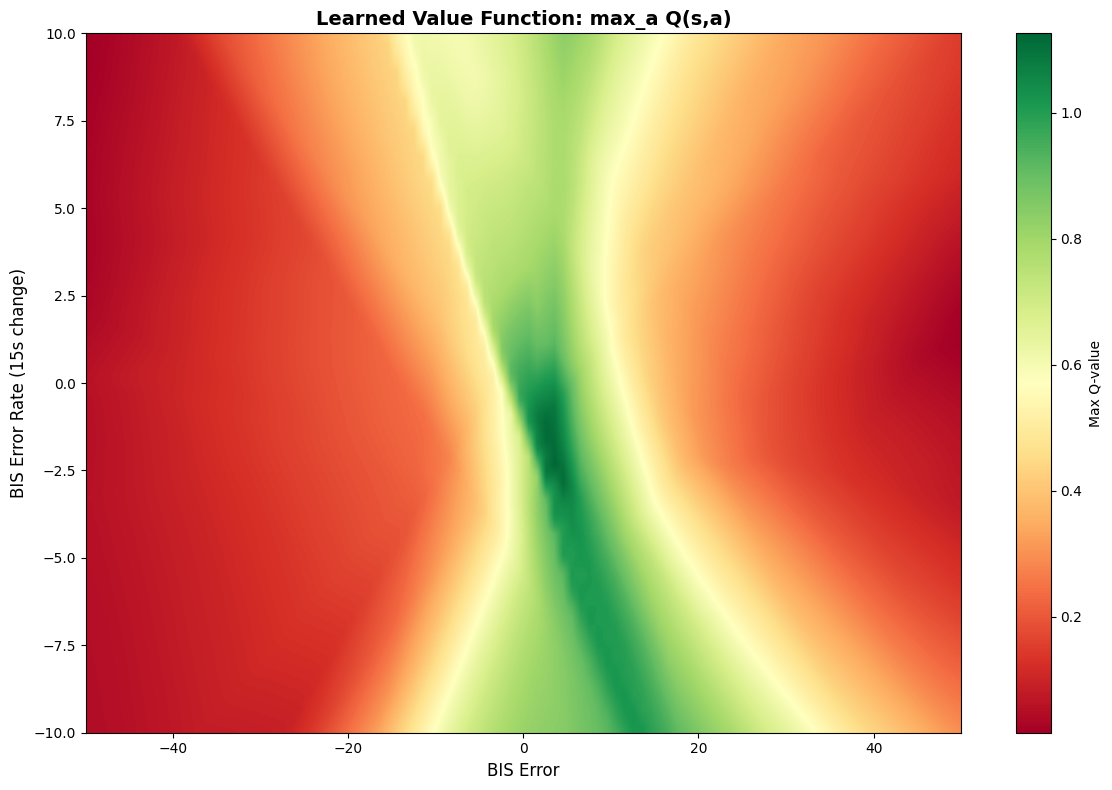

[4/5] Plotting learned policy...


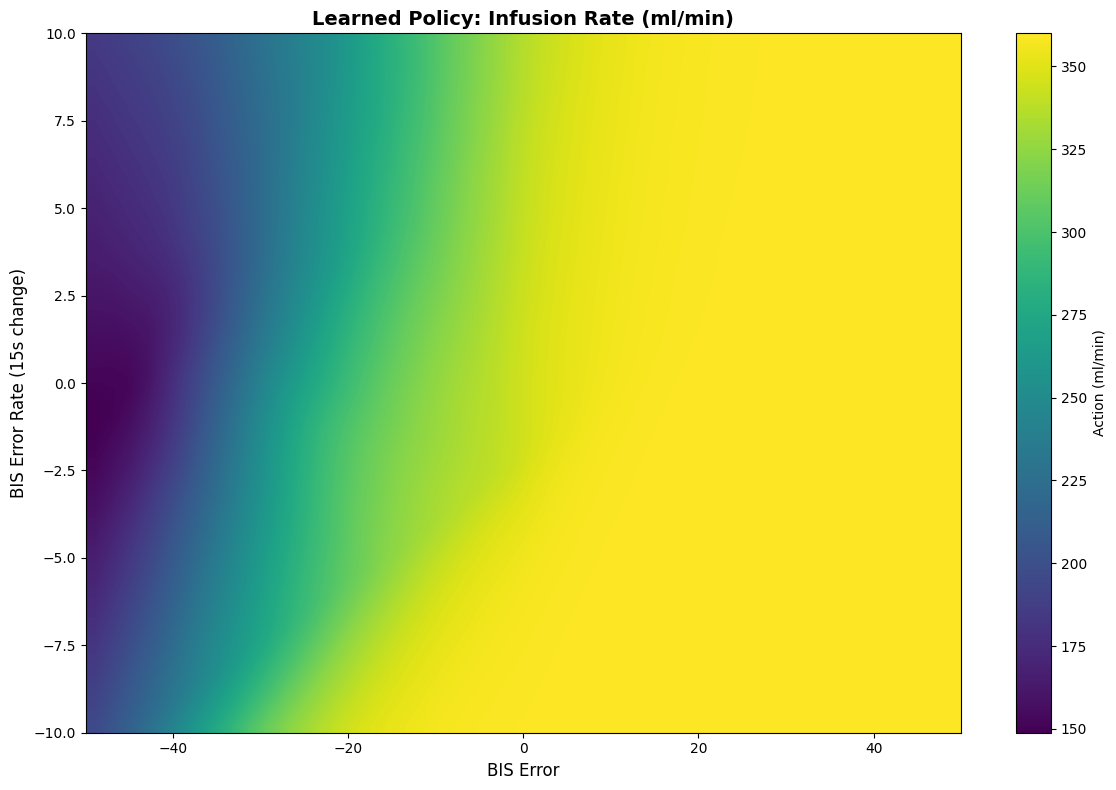

[5/5] Plotting action distribution...


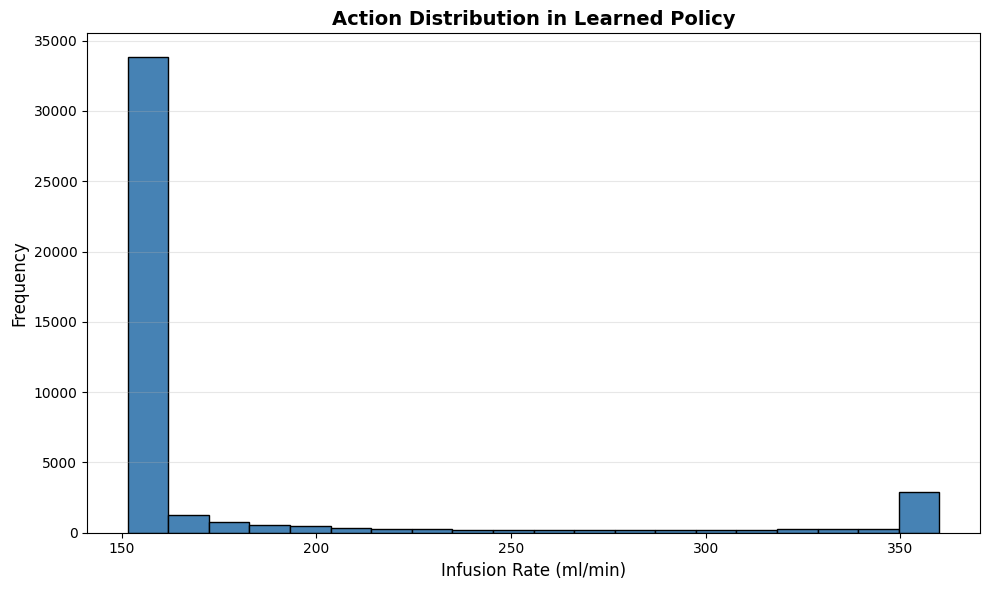


All visualizations saved to images/

1. Loading patient data from data\Patients Data.csv...
   Loaded 237630 patients

2. Sampling 500 patients...
   Sampled 500 patients

3. Generating Schnider PK/PD parameters...
   Generated parameters for 500 patients

4. Evaluating policy at 4 episode lengths...
   Processing patient 50/500...
   Processing patient 100/500...
   Processing patient 150/500...


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pandas as pd
import random
from pathlib import Path

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 2000
STEPS_PER_EPISODE = 7200
BATCH_UPDATES_PER_EP = 64

ACTOR_LR = 1e-4
CRITIC_LR = 1e-3
REPLAY_CAPACITY = 200_000
BATCH_SIZE = 128

# TD3-specific hyperparameters
GAMMA = 0.69
TAU = 0.005
POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
POLICY_DELAY = 2

# Exploration noise schedule
EXPLORATION_NOISE_START = 0.30
EXPLORATION_NOISE_END = 0.03
EXPLORATION_NOISE_DECAY = 0.97

# Early stopping (based on moving average reward)
EARLY_STOPPING_ENABLED = True
EARLY_STOPPING_WARMUP_EPISODES = 300
EARLY_STOPPING_WINDOW = 20
EARLY_STOPPING_PATIENCE = 50
EARLY_STOPPING_MIN_DELTA = 1.0

EVAL_EPISODES = 30
EVAL_STEPS_PER_EPISODE = 1440

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [3000, 6000, 12000, 36000]  # seconds
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

INTEGRATION_DT_SECONDS = 1.0
DT = INTEGRATION_DT_SECONDS / 60.0  # integration step in minutes for PK rates in min^-1
SIMULATION_STEP_SECONDS = 5.0  # keep train/eval aligned at 5-second control steps
SIMULATION_STEP_SUBSTEPS = max(1, int(SIMULATION_STEP_SECONDS / INTEGRATION_DT_SECONDS))
K10, K12, K13 = 0.119, 0.112, 0.042
K21, K31 = 0.055, 0.0033
KE0 = 0.17
V1 = 4.27

E0, EMAX, EC50, HILL_PD = 97.4, 97.4, 3.4, 1.89

# ============================================================================
# RL CONFIGURATION (CONTINUOUS ACTIONS)
# ============================================================================

ACTION_MIN = 0.0  # ml/min
ACTION_MAX = 6.0  # ml/min
N_FEAT = 2
ACTION_INTERVAL_SECONDS = 10
ACTION_INTERVAL_STEPS = max(1, int(ACTION_INTERVAL_SECONDS / SIMULATION_STEP_SECONDS))
BIS_TARGET_RANGE = (40, 60)

# ============================================================================
# REPRODUCIBILITY
# ============================================================================

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


def pk_step(C, u):
    """PK dynamics: single step forward."""
    c1, c2, c3, ce = C
    dose_rate = u * 10 / V1
    dc1 = dose_rate - (K10 + K12 + K13) * c1 + K21 * c2 + K31 * c3
    dc2 = K12 * c1 - K21 * c2
    dc3 = K13 * c1 - K31 * c3
    dce = KE0 * (c1 - ce)
    return np.array([c1 + dc1 * DT, c2 + dc2 * DT, c3 + dc3 * DT, ce + dce * DT])


def bis(ce):
    """Compute BIS from effect-site concentration."""
    return E0 - EMAX * ce**HILL_PD / (EC50**HILL_PD + ce**HILL_PD)


def features(err, derr):
    """2D state: [BIS error, delta BIS error]."""
    err_c = np.clip(err, -50.0, 50.0) / 50.0
    derr_c = np.clip(derr, -10.0, 10.0) / 10.0
    return np.array([err_c, derr_c], dtype=np.float32)


def _to_norm_action(action):
    """Map infusion from [ACTION_MIN, ACTION_MAX] to [-1, 1]."""
    scaled = 2.0 * (action - ACTION_MIN) / (ACTION_MAX - ACTION_MIN) - 1.0
    return np.clip(scaled, -1.0, 1.0)


def _from_norm_action(norm_action):
    """Map action from [-1, 1] back to infusion range [ACTION_MIN, ACTION_MAX]."""
    action = (norm_action + 1.0) * 0.5 * (ACTION_MAX - ACTION_MIN) + ACTION_MIN
    return np.clip(action, ACTION_MIN, ACTION_MAX)


# ============================================================================
# TD3 NETWORKS
# ============================================================================


class Actor(nn.Module):
    """Deterministic policy a = pi(s), output in [-1, 1]."""

    def __init__(self, state_dim=N_FEAT, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Tanh(),
        )

    def forward(self, state):
        return self.net(state)


class Critic(nn.Module):
    """Q-network for scalar continuous action."""

    def __init__(self, state_dim=N_FEAT, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state, action):
        if action.dim() == 1:
            action = action.unsqueeze(1)
        x = torch.cat([state, action], dim=1)
        return self.net(x)


# ============================================================================
# EXPERIENCE REPLAY BUFFER
# ============================================================================


class ReplayBuffer:
    """Stores (s, a_norm, r, s', done) transitions for TD3 updates."""

    def __init__(self, capacity=REPLAY_CAPACITY):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action_norm, reward, next_state, done):
        self.buffer.append((state, action_norm, reward, next_state, done))

    def sample_batch(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]

        states = torch.tensor(np.array([x[0] for x in batch]), dtype=torch.float32)
        actions = torch.tensor(np.array([x[1] for x in batch]), dtype=torch.float32).unsqueeze(1)
        rewards = torch.tensor(np.array([x[2] for x in batch]), dtype=torch.float32).unsqueeze(1)
        next_states = torch.tensor(np.array([x[3] for x in batch]), dtype=torch.float32)
        dones = torch.tensor(np.array([x[4] for x in batch]), dtype=torch.float32).unsqueeze(1)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


# ============================================================================
# CONTINUOUS AGENT (TD3)
# ============================================================================


class TD3Agent:
    """TD3 agent for continuous infusion control."""

    def __init__(
        self,
        state_dim=N_FEAT,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        gamma=GAMMA,
        tau=TAU,
        batch_size=BATCH_SIZE,
        replay_capacity=REPLAY_CAPACITY,
    ):
        self.device = torch.device("cpu")
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size

        self.actor = Actor(state_dim=state_dim).to(self.device)
        self.actor_target = Actor(state_dim=state_dim).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic_1 = Critic(state_dim=state_dim).to(self.device)
        self.critic_2 = Critic(state_dim=state_dim).to(self.device)
        self.critic_target_1 = Critic(state_dim=state_dim).to(self.device)
        self.critic_target_2 = Critic(state_dim=state_dim).to(self.device)

        self.critic_target_1.load_state_dict(self.critic_1.state_dict())
        self.critic_target_2.load_state_dict(self.critic_2.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer_1 = optim.Adam(self.critic_1.parameters(), lr=critic_lr)
        self.critic_optimizer_2 = optim.Adam(self.critic_2.parameters(), lr=critic_lr)

        self.replay_buffer = ReplayBuffer(capacity=replay_capacity)

        self.exploration_noise = EXPLORATION_NOISE_START
        self.train_step_count = 0

    def _select_action_norm(self, feat):
        with torch.no_grad():
            state_tensor = torch.tensor(feat, dtype=torch.float32, device=self.device).unsqueeze(0)
            action_norm = self.actor(state_tensor).squeeze(0).item()
        return float(np.clip(action_norm, -1.0, 1.0))

    def select_action(self, feat, training=True):
        """Returns continuous infusion action in ml/min."""
        action_norm = self._select_action_norm(feat)

        if training:
            noise = np.random.normal(0.0, self.exploration_noise)
            action_norm = float(np.clip(action_norm + noise, -1.0, 1.0))

        action = _from_norm_action(action_norm)
        return float(action)

    def update_exploration_noise(self):
        self.exploration_noise = max(
            EXPLORATION_NOISE_END,
            self.exploration_noise * EXPLORATION_NOISE_DECAY,
        )

    def store_transition(self, feat, action, reward, next_feat, done):
        action_norm = _to_norm_action(action)
        self.replay_buffer.push(feat, action_norm, reward, next_feat, done)

    @staticmethod
    def _soft_update(target_net, source_net, tau):
        for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
            target_param.data.copy_(tau * source_param.data + (1.0 - tau) * target_param.data)

    def train_step(self):
        """One TD3 update step with delayed actor update."""
        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.replay_buffer.sample_batch(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        with torch.no_grad():
            noise = torch.randn_like(actions) * POLICY_NOISE
            noise = torch.clamp(noise, -NOISE_CLIP, NOISE_CLIP)
            next_actions = self.actor_target(next_states) + noise
            next_actions = torch.clamp(next_actions, -1.0, 1.0)

            target_q1 = self.critic_target_1(next_states, next_actions)
            target_q2 = self.critic_target_2(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2)
            y = rewards + self.gamma * (1.0 - dones) * target_q

        current_q1 = self.critic_1(states, actions)
        current_q2 = self.critic_2(states, actions)

        critic_loss_1 = nn.functional.mse_loss(current_q1, y)
        critic_loss_2 = nn.functional.mse_loss(current_q2, y)

        self.critic_optimizer_1.zero_grad()
        critic_loss_1.backward()
        nn.utils.clip_grad_norm_(self.critic_1.parameters(), 1.0)
        self.critic_optimizer_1.step()

        self.critic_optimizer_2.zero_grad()
        critic_loss_2.backward()
        nn.utils.clip_grad_norm_(self.critic_2.parameters(), 1.0)
        self.critic_optimizer_2.step()

        self.train_step_count += 1

        if self.train_step_count % POLICY_DELAY == 0:
            actor_actions = self.actor(states)
            actor_loss = -self.critic_1(states, actor_actions).mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
            self.actor_optimizer.step()

            self._soft_update(self.actor_target, self.actor, self.tau)
            self._soft_update(self.critic_target_1, self.critic_1, self.tau)
            self._soft_update(self.critic_target_2, self.critic_2, self.tau)

        return float((critic_loss_1.item() + critic_loss_2.item()) * 0.5)


# ============================================================================
# TRAINING SECTION
# ============================================================================


def train(n_episodes=EPISODES, ep_len=STEPS_PER_EPISODE, batch_updates_per_ep=BATCH_UPDATES_PER_EP):
    """Train TD3 agent and track episode reward / critic loss."""
    agent = TD3Agent(
        state_dim=N_FEAT,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        gamma=GAMMA,
        tau=TAU,
        batch_size=BATCH_SIZE,
        replay_capacity=REPLAY_CAPACITY,
    )

    episode_rewards = []
    episode_losses = []

    best_mavg_reward = -np.inf
    best_checkpoint = None
    no_improve_count = 0

    for ep in range(n_episodes):
        target = np.random.uniform(*BIS_TARGET_RANGE)
        c0 = np.random.uniform(0.5, 4.0)
        C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])

        err_prev = bis(C[3]) - target
        BIS_TARGET_MIN, BIS_TARGET_MAX = BIS_TARGET_RANGE
        CONSECUTIVE_TARGET_STEPS = 1200
        consecutive_within_target = 0

        ep_reward = 0.0
        derr_prev = 0.0
        last_action = agent.select_action(features(err_prev, derr_prev), training=True)

        episode_steps = max(1, int(ep_len / SIMULATION_STEP_SECONDS))
        for step in range(episode_steps):
            feat = features(err_prev, derr_prev)

            if step % ACTION_INTERVAL_STEPS == 0:
                last_action = agent.select_action(feat, training=True)

            for _ in range(SIMULATION_STEP_SUBSTEPS):
                C = pk_step(C, last_action)
            C = np.maximum(C, 0.0)
            current_bis = bis(C[3])

            err = current_bis - target
            derr = err - err_prev

            reward_tracking = 1.0 / (1.0 + abs(err))
            reward_stability = 1.0 / (1.0 + abs(derr))
            if BIS_TARGET_MIN <= current_bis:
                r = 1.0/(1.0+abs(err))
            else:
                r=-2.0*abs(err)
                
            if BIS_TARGET_MIN <= current_bis <= BIS_TARGET_MAX:
                consecutive_within_target += 1
            else:
                consecutive_within_target = 0

            done = bool(consecutive_within_target >= CONSECUTIVE_TARGET_STEPS or step == episode_steps - 1)
            feat_next = features(err, derr)

            agent.store_transition(feat, last_action, r, feat_next, done)

            ep_reward += r
            derr_prev = derr
            err_prev = err

            if done:
                break

        ep_loss = 0.0
        loss_updates = 0
        for _ in range(batch_updates_per_ep):
            loss = agent.train_step()
            if loss > 0:
                ep_loss += loss
                loss_updates += 1

        agent.update_exploration_noise()

        episode_rewards.append(ep_reward)
        episode_losses.append(ep_loss / max(loss_updates, 1))

        if (ep + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            avg_loss = np.mean(episode_losses[-10:])
            print(
                f"Episode {ep + 1}/{n_episodes} | "
                f"Avg Reward(10): {avg_reward:.2f} | Avg Loss(10): {avg_loss:.4f} | "
                f"ExplNoise: {agent.exploration_noise:.4f}"
            )

        if EARLY_STOPPING_ENABLED and (ep + 1) >= EARLY_STOPPING_WARMUP_EPISODES:
            mavg_reward = np.mean(episode_rewards[-EARLY_STOPPING_WINDOW:])
            if mavg_reward > (best_mavg_reward + EARLY_STOPPING_MIN_DELTA):
                best_mavg_reward = mavg_reward
                no_improve_count = 0
                best_checkpoint = {
                    "actor": {k: v.detach().clone() for k, v in agent.actor.state_dict().items()},
                    "critic_1": {k: v.detach().clone() for k, v in agent.critic_1.state_dict().items()},
                    "critic_2": {k: v.detach().clone() for k, v in agent.critic_2.state_dict().items()},
                }
            else:
                no_improve_count += 1

            if no_improve_count >= EARLY_STOPPING_PATIENCE:
                print(
                    f"Early stopping at episode {ep + 1}: moving-average reward did not improve for {EARLY_STOPPING_PATIENCE} checks."
                )
                break

    if best_checkpoint is not None:
        agent.actor.load_state_dict(best_checkpoint["actor"])
        agent.critic_1.load_state_dict(best_checkpoint["critic_1"])
        agent.critic_2.load_state_dict(best_checkpoint["critic_2"])

    print("Training complete.")
    return agent, episode_rewards, episode_losses


# ============================================================================
# EVALUATION & SAVING
# ============================================================================


try:
    from utils.rl_visualization_continuous import (
        evaluate_policy as _evaluate_policy,
        plot_training_curves as _plot_training_curves,
        plot_bis_trajectory as _plot_bis_trajectory,
        plot_q_values_heatmap as _plot_q_values_heatmap,
        plot_policy_heatmap as _plot_policy_heatmap,
        plot_action_distribution as _plot_action_distribution,
    )
except Exception:
    try:
        from utils.rl_visualization_fixed import (
            evaluate_policy as _evaluate_policy,
            plot_training_curves as _plot_training_curves,
            plot_bis_trajectory as _plot_bis_trajectory,
            plot_q_values_heatmap as _plot_q_values_heatmap,
            plot_policy_heatmap as _plot_policy_heatmap,
            plot_action_distribution as _plot_action_distribution,
        )
    except Exception:
        from utils.rl_visualization import (
            evaluate_policy as _evaluate_policy,
            plot_training_curves as _plot_training_curves,
            plot_bis_trajectory as _plot_bis_trajectory,
            plot_q_values_heatmap as _plot_q_values_heatmap,
            plot_policy_heatmap as _plot_policy_heatmap,
            plot_action_distribution as _plot_action_distribution,
        )


def evaluate(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE):
    return _evaluate_policy(
        agent=agent,
        n_episodes=n_episodes,
        ep_len=ep_len,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
    )


def plot_training_curves(rewards, losses):
    return _plot_training_curves(rewards, losses, save_path="images/training_curves.png")


def plot_bis_trajectory(agent, ep_len=EVAL_STEPS_PER_EPISODE, target=None):
    if target is None:
        target = np.mean(BIS_TARGET_RANGE)
    return _plot_bis_trajectory(
        agent=agent,
        ep_len=ep_len,
        target=target,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
        save_path="images/bis_trajectory.png",
    )


def plot_q_values_heatmap(agent, n_samples=100):
    action_grid = np.linspace(-1.0, 1.0, 25, dtype=np.float32)

    def _q_max_fn(err, derr):
        feat = features(err, derr)
        with torch.no_grad():
            state = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).repeat(len(action_grid), 1)
            actions = torch.tensor(action_grid, dtype=torch.float32).unsqueeze(1)
            q_vals = agent.critic_1(state, actions).squeeze(1).cpu().numpy()
            return float(np.max(q_vals))

    return _plot_q_values_heatmap(
        n_samples=n_samples,
        q_max_fn=_q_max_fn,
        save_path="images/q_values_heatmap.png",
    )


def plot_policy_heatmap(agent, n_samples=50):
    return _plot_policy_heatmap(
        agent=agent,
        n_samples=n_samples,
        features_fn=features,
        save_path="images/policy_heatmap.png",
    )


def plot_action_distribution(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE):
    return _plot_action_distribution(
        agent=agent,
        n_episodes=n_episodes,
        ep_len=ep_len,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
        save_path="images/action_distribution.png",
    )


def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)


class DQNEvaluator:
    def __init__(self, agent):
        self.agent = agent
        self.target = 50.0

    def simulate(self, patient_row, duration_seconds):
        duration_steps = max(1, int(duration_seconds / SIMULATION_STEP_SECONDS))
        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        prev_error = 0.0
        last_action = self.agent.select_action(features(0.0, 0.0), training=False)

        for step in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            ce_h = np.power(ce, HILL_PD)
            ec50_h = np.power(EC50, HILL_PD)

            if ce_h + ec50_h > 0:
                bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = E0

            measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 3), 0, 100)
            error = np.clip(float(measured_bis - self.target), -50.0, 50.0)
            derr = np.clip(float(error - prev_error), -10.0, 10.0)

            feat = features(error, derr)
            if step % ACTION_INTERVAL_STEPS == 0:
                last_action = self.agent.select_action(feat, training=False)

            u = float(np.clip(last_action, ACTION_MIN, ACTION_MAX))
            for _ in range(SIMULATION_STEP_SUBSTEPS):
                x_dot = A @ x + B * u
                x = x + x_dot * DT
            x = np.clip(x, -10.0, 10.0)

            bis_log.append(float(measured_bis))
            prev_error = error

        return np.array(bis_log)


if __name__ == "__main__":
    agent, rewards, losses = train(
        n_episodes=EPISODES,
        ep_len=STEPS_PER_EPISODE,
        batch_updates_per_ep=BATCH_UPDATES_PER_EP,
    )

    eval_rewards = evaluate(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE)
    print(f"Evaluation episodes: {len(eval_rewards)}")

    model_bundle = {
        "actor": agent.actor.state_dict(),
        "critic_1": agent.critic_1.state_dict(),
        "critic_2": agent.critic_2.state_dict(),
    }
    torch.save(model_bundle, ARTIFACTS_DIR / "dqn_bis_deltabis_network.pth")
    np.save(ARTIFACTS_DIR / "dqn_bis_deltabis_rewards.npy", np.array(rewards))
    np.save(ARTIFACTS_DIR / "dqn_bis_deltabis_losses.npy", np.array(losses))
    print(f"\nModel saved to {ARTIFACTS_DIR / 'dqn_bis_deltabis_network.pth'}")
    print("Training history saved to artifacts/dqn_bis_deltabis_*.npy")

    print("\n" + "=" * 70)
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    print("\n[1/5] Plotting training curves...")
    plot_training_curves(rewards, losses)

    print("[2/5] Plotting BIS trajectory...")
    plot_bis_trajectory(agent, ep_len=STEPS_PER_EPISODE, target=50.0)

    print("[3/5] Plotting Q-values heatmap...")
    plot_q_values_heatmap(agent, n_samples=100)

    print("[4/5] Plotting learned policy...")
    plot_policy_heatmap(agent, n_samples=50)

    print("[5/5] Plotting action distribution...")
    plot_action_distribution(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE)

    print("\n" + "=" * 70)
    print("All visualizations saved to images/")
    print("=" * 70)

    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    print(f"\n1. Loading patient data from {DATA_PATH}...")
    df = load_data(DATA_PATH)
    df = preprocess_data(df)
    print(f"   Loaded {len(df)} patients")

    print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
    sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
    print(f"   Sampled {len(sample_df)} patients")

    print("\n3. Generating Schnider PK/PD parameters...")
    eval_df = generate_schnider_dataset(sample_df)
    print(f"   Generated parameters for {len(eval_df)} patients")

    evaluator = DQNEvaluator(agent)

    print(f"\n4. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
    patient_results = []

    for idx, (_, patient) in enumerate(eval_df.iterrows()):
        if (idx + 1) % 50 == 0:
            print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

        patient_id = patient["PatientID"]
        age = patient["AgeCategory"]
        age_group = get_age_group(age, AGE_GROUPS)

        results = {}
        for ep_len in EVAL_EPISODE_LENGTHS:
            bis_traj = evaluator.simulate(patient, ep_len)
            metrics = calculate_bis_metrics(bis_traj, 50.0)
            results[ep_len] = metrics

        patient_results.append(
            {
                "patient_id": patient_id,
                "age": age,
                "age_group": age_group,
                "results": results,
            }
        )

    results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
    summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

    print("\n5. Saving evaluation results (JSON format)...")
    save_evaluation_results(
        results_df,
        summary_df,
        "dqn_bis_deltabis",
        str(METRICS_DIR),
    )
    print(f"   Saved: {METRICS_DIR / 'dqn_bis_deltabis_results.json'}")
    print(f"   Saved: {METRICS_DIR / 'dqn_bis_deltabis_summary.json'}")